# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 140 packages in 4.03s
Prepared 45 packages in 44.08s
Uninstalled 23 packages in 831ms
Installed 45 packages in 489ms
 - click==8.3.1
 + click==8.1.8
 + cyclopts==4.10.2
 - decorator==4.4.2
 + decorator==5.2.1
 + exca==0.5.22
 + gtts==2.5.4
 + julius==0.2.7
 + langdetect==1.0.9
 + levenshtein==0.27.3
 + lightning-utilities==0.15.3
 + mne==1.12.0
 + mne-bids==0.18.0
 - moviepy==1.0.3
 + moviepy==2.2.1
 + neuralset==0.0.2
 + neuraltrain==0.0.2
 + nilearn==0.13.1
 - numpy==2.0.2
 + numpy==2.2.6
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-cur

## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [1]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-09 22:16:34 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access pu

config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-09 22:16:45 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [2]:
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)
df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
INFO:tribev2.demo_utils:Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in cache/sample_video.wav



Extract audio from video events: 100%|██████████| 1/1 [00:01<00:00,  1.50s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


Extracting words from audio: 100%|██████████| 1/1 [02:47<00:00, 167.92s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Add context to words: 100%|██████████| 30/30 [00:00<00:00, 73886.74it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,52.210000,cache/sample_video.wav,NaN,
1,Video,0.000000,52.210000,cache/sample_video.mp4,NaN,
2,Sentence,12.212999,2.042002,NaN,What brings you to the land of the gatekeepers?.,
3,Text,12.213000,31.490000,NaN,What brings you to the land of the gatekeepers...,
4,Word,12.213000,0.120000,NaN,What,What
5,Word,12.393000,0.280000,NaN,brings,What brings
6,Word,12.713000,0.101000,NaN,you,What brings you
7,Word,12.854000,0.100000,NaN,to,What brings you to


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [4]:
!hf auth login

A new version of huggingface_hub (1.10.1) is available! You are using version 1.8.0.
To update, run: pip install -U huggingface_hub


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: n
Token is valid (permission: fineGrained).
The token `colab` has been saved to /root/.cache/huggingface/

In [8]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[22:25:21 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text



  0%|          | 0/30 [00:00<?, ?it/s]



Computing word embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json: 0.00B [00:00, ?B/s]

2026-04-09 22:28:37 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 52.21s at 24.0fps, shape (854, 480)):
cache/sample_video.mp4
Encoding video:   0%|          | 0/104 [00:00<?, ?it/s]2026-04-09 22:28:53 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (104, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (104, 20, 1408)
Encoding video: 100%|██████████| 104/104 [27:27<00:00, 15.84s/it]
[22:56:05 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-09 22:56:05 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[22:56:05 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: 

Predictions shape: (53, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 15/15 [00:03<00:00,  4.05it/s]


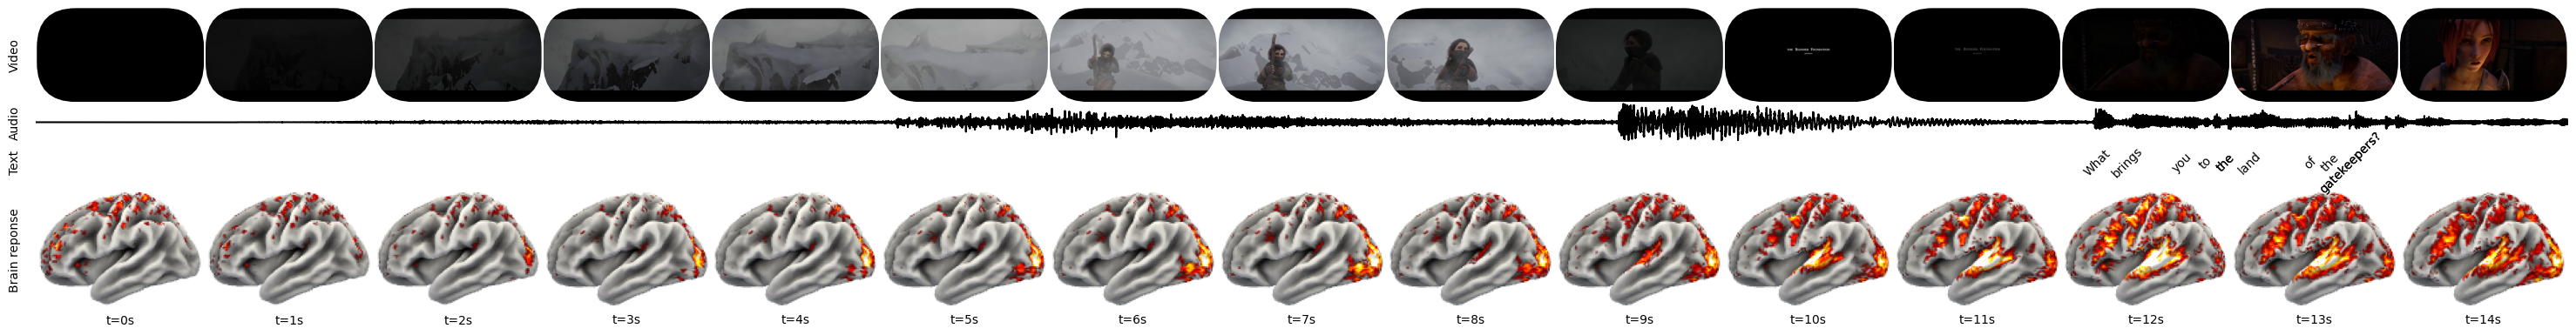

In [9]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [10]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-To-be-or-not-to-be,-that-is-the-question.-Whether-tis-nobler-in-the-mind-to-suffer-The-slings-and-arrows-of-outrageous-for...11-44470b46/audio.mp3
INFO:tribev2.demo_utils:Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=-To-be-or-not-to-be,-that-is-the-question.-Whether-tis-nobler-in-the-mind-to-suffer-The-slings-and-arrows-of-outrageous-for...11-44470b46/audio.mp3
Extracting words from audio: 100%|██████████| 1/1 [00:56<00:00, 56.09s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 60/60 [00:00<00:00, 136994.14it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,23.256000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.090999,1.261002,NaN,To be or not to be.,
2,Text,0.091000,22.610000,NaN,To be or not to be. That is the question. Whet...,
3,Word,0.091000,0.100000,NaN,To,To
4,Word,0.271000,0.200000,NaN,be,To be
5,Word,0.551000,0.060000,NaN,or,To be or
6,Word,0.691000,0.200000,NaN,not,To be or not
7,Word,0.931000,0.100000,NaN,to,To be or not to


### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [11]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[23:02:33 WARNING] Removing extractor video as there are no corresponding events
[23:02:33 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/15 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

100%|██████████| 60/60 [00:40<00:00,  1.47it/s]

Computing word embeddings: 100%|██████████| 15/15 [00:40<00:00,  2.73s/it]
[23:03:15 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[23:03:28 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-09 23:03:28 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[23:03:29 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:02<00:00,  2.16s/it]
INFO - Predicted 24 / 100 segments (24.0% kept)
INFO:tribev2.demo_utils:Predicted 24 / 100 segments (24.0% kept)


Predictions shape: (24, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  5.21it/s]


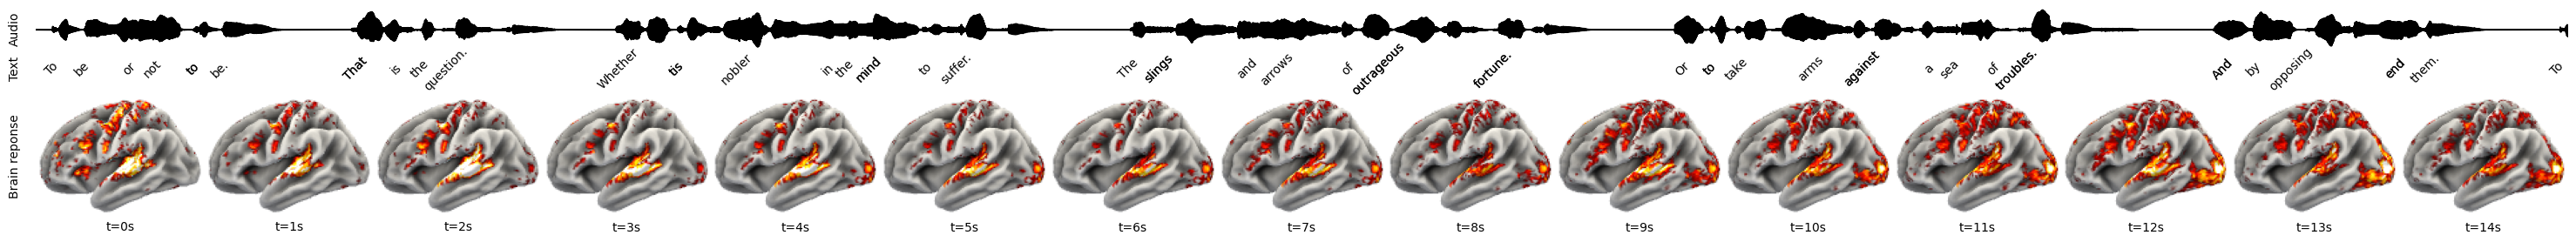

In [12]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

In [15]:
!pip install brainiak numpy nibabel

In [16]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

In [18]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

CACHE_FOLDER = Path("./cache")
PARCELLATION_DIR = CACHE_FOLDER / "schaefer"
PARCELLATION_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. DOWNLOAD SCHAEFER 400-PARCEL 7-NETWORK ATLAS (fsaverage5)
# ============================================================

SCHAEFER_BASE = (
    "https://raw.githubusercontent.com/ThomasYeoLab/CBIG/master/"
    "stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/"
    "Parcellations/FreeSurfer5.3/fsaverage5/label"
)
ANNOT_NAME = "Schaefer2018_400Parcels_7Networks_order.annot"

def fetch_schaefer_fsaverage5():
    """Download Schaefer 7-network parcellation for fsaverage5."""
    paths = {}
    for hemi in ("lh", "rh"):
        local = PARCELLATION_DIR / f"{hemi}.{ANNOT_NAME}"
        if not local.exists():
            url = f"{SCHAEFER_BASE}/{hemi}.{ANNOT_NAME}"
            print(f"Downloading {hemi} parcellation...")
            urlretrieve(url, local)
        paths[hemi] = local
    return paths

annot_paths = fetch_schaefer_fsaverage5()

# ============================================================
# 2. PARSE PARCELLATION → NETWORK MASKS
# ============================================================

# Schaefer parcel names encode their network:
#   "7Networks_LH_DorsAttn_Post_1" → DorsAttn
#   "7Networks_RH_Default_PFC_2"   → Default

NETWORK_ALIASES = {
    "DorsAttn":  "DAN",       # dorsal attention → focused attention
    "Default":   "DMN",       # default mode → mind wandering
    "Cont":      "FPN",       # control / frontoparietal → cognitive control
    "SalVentAttn": "VAN",     # salience / ventral attention
    "Limbic":    "Limbic",    # limbic → emotion
    "SomMot":    "SomMot",    # somatomotor
    "Vis":       "Vis",       # visual
}

def parse_parcellation(annot_path):
    """Load .annot file, return {network_name: vertex_indices}."""
    labels, ctab, names = nib.freesurfer.read_annot(annot_path)
    names = [n.decode() if isinstance(n, bytes) else n for n in names]

    networks = {}
    for idx, name in enumerate(names):
        # Extract network from parcel name: "7Networks_LH_DorsAttn_Post_1"
        parts = name.split("_")
        if len(parts) >= 3 and parts[0] == "7Networks":
            raw_network = parts[2]
            network = NETWORK_ALIASES.get(raw_network, raw_network)
            if network not in networks:
                networks[network] = []
            networks[network].extend(np.where(labels == idx)[0].tolist())

    # Convert to numpy arrays
    return {k: np.array(v) for k, v in networks.items()}


networks_lh = parse_parcellation(annot_paths["lh"])
networks_rh = parse_parcellation(annot_paths["rh"])

print("Networks found:")
for name in networks_lh:
    n_lh = len(networks_lh[name])
    n_rh = len(networks_rh[name])
    print(f"  {name:8s}: {n_lh + n_rh:5d} vertices ({n_lh} LH + {n_rh} RH)")


# ============================================================
# 3. EXTRACT NETWORK SIGNALS FROM TRIBEV2 PREDICTIONS
# ============================================================

N_VERTICES_HEMI = 10242  # fsaverage5

def extract_network_signals(preds):
    """
    Extract mean activation per network from TRIBEv2 surface predictions.

    Args:
        preds: np.ndarray, shape (n_timesteps, 20484) — TRIBEv2 output
               First 10242 = LH, next 10242 = RH

    Returns:
        dict[str, np.ndarray]: network_name → (n_timesteps,) signal
    """
    preds_lh = preds[:, :N_VERTICES_HEMI]
    preds_rh = preds[:, N_VERTICES_HEMI:2 * N_VERTICES_HEMI]

    signals = {}
    for network in networks_lh:
        lh_idx = networks_lh[network]
        rh_idx = networks_rh.get(network, np.array([], dtype=int))

        sig_lh = preds_lh[:, lh_idx].mean(axis=1) if len(lh_idx) > 0 else 0
        sig_rh = preds_rh[:, rh_idx].mean(axis=1) if len(rh_idx) > 0 else 0

        signals[network] = (sig_lh + sig_rh) / 2  # bilateral average

    return signals


def compute_cognitive_metrics(signals):
    """Compute cognitive load, attention, and engagement from network signals."""
    return {
        # Cognitive load: high control + high attention - low DMN
        "cognitive_load": (
            np.mean(signals["FPN"]) +
            np.mean(signals["DAN"]) -
            np.mean(signals["DMN"])
        ),
        # Attention: DAN - DMN anticorrelation
        "attention": np.mean(signals["DAN"]) - np.mean(signals["DMN"]),
        # Engagement: inverse of DMN (less mind-wandering = more engaged)
        "engagement": -np.mean(signals["DMN"]),
        # Per-network means
        **{f"net_{k}": np.mean(v) for k, v in signals.items()},
    }


# ============================================================
# 4. BRAINIAK: REPRESENTATIONAL SIMILARITY ANALYSIS
# ============================================================

def run_brsa(predictions_dict, n_events=None):
    """
    Bayesian RSA across stimulus conditions using BrainIAK.

    Args:
        predictions_dict: {condition_name: preds array (n_timesteps, n_vertices)}

    Returns:
        similarity_matrix: (n_conditions, n_conditions) correlation matrix
        condition_names: list of condition names
    """
    from brainiak.reprsimil.brsa import BRSA

    conditions = list(predictions_dict.keys())
    all_preds = []
    design_rows = []

    for i, (name, preds) in enumerate(predictions_dict.items()):
        all_preds.append(preds)
        # One-hot design: which condition is active at each timepoint
        col = np.zeros((preds.shape[0], len(conditions)))
        col[:, i] = 1.0
        design_rows.append(col)

    # Stack all conditions into one timeseries
    X = np.vstack(all_preds)          # (total_timesteps, n_vertices)
    design = np.vstack(design_rows)   # (total_timesteps, n_conditions)

    # Subsample vertices for speed (BRSA on 20k vertices is slow)
    n_verts_sample = min(500, X.shape[1])
    rng = np.random.default_rng(42)
    vert_idx = rng.choice(X.shape[1], n_verts_sample, replace=False)
    X_sub = X[:, vert_idx]

    print(f"Running BRSA: {X_sub.shape[0]} timepoints × {n_verts_sample} vertices, "
          f"finding {len(conditions)} conditions...")

    brsa = BRSA(n_iter=200, auto_nuisance=True)
    brsa.fit(X_sub, design)

    # brsa.U_ is the shared covariance (n_conditions × n_conditions)
    # Normalize to correlation matrix
    U = brsa.U_
    d = np.sqrt(np.diag(U))
    d[d == 0] = 1
    similarity = U / np.outer(d, d)

    return similarity, conditions


# ============================================================
# 5. BRAINIAK: EVENT SEGMENTATION
# ============================================================

def find_cognitive_state_boundaries(preds, n_events=5):
    """
    Use BrainIAK's HMM-based event segmentation to find
    cognitive state transitions in the predicted brain response.

    Args:
        preds: (n_timesteps, n_vertices) — TRIBEv2 output
        n_events: number of discrete cognitive states to find

    Returns:
        event_labels: (n_timesteps,) — which state each timepoint belongs to
        boundaries: list of timepoint indices where state transitions occur
    """
    from brainiak.eventseg.event import EventSegment

    # Subsample vertices for speed
    n_verts_sample = min(500, preds.shape[1])
    rng = np.random.default_rng(42)
    vert_idx = rng.choice(preds.shape[1], n_verts_sample, replace=False)
    X = preds[:, vert_idx]

    print(f"Running EventSegment: {X.shape[0]} timepoints × {n_verts_sample} vertices, "
          f"finding {n_events} states...")

    ev = EventSegment(n_events=n_events)
    ev.fit(X)

    # ev.segments_[0] is (n_timesteps, n_events) probability matrix
    event_probs = ev.segments_[0]
    event_labels = np.argmax(event_probs, axis=1)

    # Find boundaries (where label changes)
    boundaries = np.where(np.diff(event_labels) != 0)[0] + 1

    return event_labels, boundaries


# ============================================================
# 6. FULL PIPELINE: STIMULI → TRIBEV2 → QUANTIFY → PLOT
# ============================================================

def run_pipeline(model, stimuli_dict):
    """
    End-to-end: text stimuli → TRIBEv2 → cognitive metrics + RSA + event segmentation.

    Args:
        model: TribeModel instance (already loaded)
        stimuli_dict: {level_name: text_string}
    """
    # --- Run TRIBEv2 predictions ---
    predictions = {}
    for level, text in stimuli_dict.items():
        text_path = CACHE_FOLDER / f"{level}.txt"
        text_path.write_text(text.strip())
        df = model.get_events_dataframe(text_path=text_path)
        preds, segments = model.predict(events=df)
        predictions[level] = preds
        print(f"  {level:15s} → {preds.shape}")

    # --- Extract network signals & cognitive metrics ---
    all_metrics = {}
    all_signals = {}
    for level, preds in predictions.items():
        signals = extract_network_signals(preds)
        metrics = compute_cognitive_metrics(signals)
        all_signals[level] = signals
        all_metrics[level] = metrics

    # --- Print metrics table ---
    levels = list(stimuli_dict.keys())
    print("\n" + "=" * 75)
    print(f"{'Stimulus':<15s} {'Cog Load':>10s} {'Attention':>10s} "
          f"{'Engage':>10s} {'FPN':>8s} {'DAN':>8s} {'DMN':>8s}") # Fixed print statement
    print("=" * 75)
    for level in levels:
        m = all_metrics[level]
        print(f"{level:15s} {m['cognitive_load']:10.4f} {m['attention']:10.4f} "
              f"{m['engagement']:10.4f} {m['net_FPN']:8.4f} {m['net_DAN']:8.4f} "
              f"{m['net_DMN']:8.4f}")

    # --- BRSA: how similar are the brain response patterns? ---
    print("\n--- Bayesian RSA ---")
    sim_matrix, cond_names = run_brsa(predictions)

    # --- Event segmentation on the most complex stimulus ---
    most_complex = levels[-1]
    print(f"\n--- Event Segmentation ({most_complex}) ---")
    event_labels, boundaries = find_cognitive_state_boundaries(
        predictions[most_complex], n_events=5
    )
    print(f"  Found {len(boundaries)} state transitions at timepoints: {boundaries}")

    # --- Plot everything ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # (A) Cognitive load bar chart
    ax = axes[0, 0]
    colors = ["#22c55e", "#4a9eed", "#f59e0b", "#ef4444"][:len(levels)]
    vals = [all_metrics[l]["cognitive_load"] for l in levels]
    ax.bar(levels, vals, color=colors)
    ax.set_title("Cognitive Load Index (FPN + DAN - DMN)")
    ax.set_ylabel("Load")
    ax.tick_params(axis="x", rotation=15)

    # (B) Network breakdown
    ax = axes[0, 1]
    x = np.arange(len(levels))
    width = 0.15
    for i, net in enumerate(["FPN", "DAN", "DMN", "VAN", "Vis"]):
        vals = [all_metrics[l].get(f"net_{net}", 0) for l in levels]
        ax.bar(x + i * width, vals, width, label=net)
    ax.set_xticks(x + 2 * width)
    ax.set_xticklabels(levels, rotation=15)
    ax.set_title("Network Activation Breakdown")
    ax.legend(fontsize=8)

    # (C) RSA similarity matrix
    ax = axes[1, 0]
    im = ax.imshow(sim_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cond_names)))
    ax.set_yticks(range(len(cond_names)))
    ax.set_xticklabels(cond_names, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(cond_names, fontsize=9)
    ax.set_title("Bayesian RSA (Pattern Similarity)")
    plt.colorbar(im, ax=ax, shrink=0.8)

    # (D) Event segmentation timeline
    ax = axes[1, 1]
    t = np.arange(len(event_labels))
    ax.fill_between(t, event_labels, alpha=0.6, step="mid", color="#8b5cf6")
    for b in boundaries:
        ax.axvline(b, color="#ef4444", linestyle="--", alpha=0.7, linewidth=1)
    ax.set_xlabel("Timepoint (TR)")
    ax.set_ylabel("Cognitive State")
    ax.set_title(f"Event Segmentation — {most_complex}")
    ax.set_yticks(range(5))

    plt.tight_layout()
    plt.savefig(CACHE_FOLDER / "braingym_quantification.png", dpi=150)
    plt.show()

    return all_metrics, sim_matrix, event_labels, boundaries


# ============================================================
# 7. EXAMPLE STIMULI (varying cognitive load)
# ============================================================

STIMULI = {
    "simple": """
        The sun is warm. The sky is blue. Birds fly in the air.
        Dogs like to run. Cats like to sleep. Fish swim in water.
        Trees grow tall. Flowers smell nice. Rain falls from clouds.
    """,
    "narrative": """
        To be or not to be, that is the question.
        Whether 'tis nobler in the mind to suffer
        the slings and arrows of outrageous fortune,
        or to take arms against a sea of troubles
        and by opposing end them. To die, to sleep,
        no more; and by a sleep to say we end
        the heartache and the thousand natural shocks
        that flesh is heir to.
    """,
    "technical": """
        The mitochondrial electron transport chain consists of four
        protein complexes embedded in the inner mitochondrial membrane.
        Complex I, NADH dehydrogenase, catalyzes the transfer of electrons
        from NADH to ubiquinone, coupled with the translocation of four
        protons across the membrane, establishing the electrochemical
        gradient essential for oxidative phosphorylation via ATP synthase.
    """,
    "dense": """
        The renormalization group analysis of quantum chromodynamics
        reveals asymptotic freedom at high energies, where the running
        coupling constant alpha_s decreases logarithmically. The beta
        function coefficient b_0 equals 33 minus 2n_f over 12 pi,
        governing one-loop evolution and implying confinement at low
        momentum transfer through infrared slavery of the gluon
        propagator in the Landau gauge.
    """,
}

metrics, rsa, events, bounds = run_pipeline(model, STIMULI)

Networks found:
  Vis     :  2826 vertices (1423 LH + 1403 RH)
  SomMot  :  3626 vertices (1777 LH + 1849 RH)
  DAN     :  2089 vertices (1061 LH + 1028 RH)
  VAN     :  2363 vertices (1108 LH + 1255 RH)
  Limbic  :  1383 vertices (722 LH + 661 RH)
  FPN     :  2277 vertices (931 LH + 1346 RH)
  DMN     :  4177 vertices (2350 LH + 1827 RH)


INFO - Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=The-sun-is-warm.-The-sky-is-blue.-Birds-fly-in-the-air.---------Dogs-like-to-run.-Cats-like-to-sleep.-Fish-swim-in-water.--...10-5e202b26/audio.mp3
INFO:tribev2.demo_utils:Wrote TTS audio to cache/tribev2.demo_utils.TextToEvents.get_events,0/text=The-sun-is-warm.-The-sky-is-blue.-Birds-fly-in-the-air.---------Dogs-like-to-run.-Cats-like-to-sleep.-Fish-swim-in-water.--...10-5e202b26/audio.mp3
Extracting words from audio: 100%|██████████| 1/1 [00:59<00:00, 59.50s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 35/35 [00:00<00:00, 75905.19it/s]
[23:29:18 WARNING] Removing extractor video as there are no corresponding events
[23:29:18 INFO] Preparing extractor: text
I

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

100%|██████████| 35/35 [00:33<00:00,  1.05it/s]

  0%|          | 0/30 [1:06:36<?, ?it/s]
[23:29:52 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

...

[23:35:24 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-09 23:35:24 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[23:35:25 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:02<00:00,  2.38s/it]
INFO - Predicted 35 / 100 segments (35.0% kept)
INFO:tribev2.demo_utils:Predicted 35 / 100 segments (35.0% kept)


  dense           → (35, 20484)

'''''''''''''''   Cog Load  Attention     Engage      FPN      DAN      DMN
simple              0.0981     0.1191     0.0948  -0.0210   0.0243  -0.0948
narrative           0.1536     0.1064     0.0251   0.0472   0.0813  -0.0251
technical           0.1023     0.0812     0.0463   0.0211   0.0349  -0.0463
dense               0.1164     0.0180    -0.0650   0.0984   0.0830   0.0650

--- Bayesian RSA ---


Running BRSA: 110 timepoints × 500 vertices, 4 conditions...


/usr/local/lib/python3.12/dist-packages/brainiak/reprsimil/brsa.py:2411: RuntimeWarning: overflow encountered in exp
  SNR2 = np.exp(log_SNR2)
/usr/local/lib/python3.12/dist-packages/brainiak/reprsimil/brsa.py:1188: RuntimeWarning: overflow encountered in multiply
  LAMBDA_i = LTXTAcorrXL * SNR2[:, None, None] + np.eye(rank)


LinAlgError: Singular matrix